In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

import os
import shutil
import random
from pathlib import Path
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

YOLO_ROOT = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "flir",
    "flir_yolo"
)

TRAIN_IMAGES = os.path.join(YOLO_ROOT, "images", "train")
TRAIN_LABELS = os.path.join(YOLO_ROOT, "labels", "train")

VAL_IMAGES = os.path.join(YOLO_ROOT, "images", "val")
VAL_LABELS = os.path.join(YOLO_ROOT, "labels", "val")

In [ ]:
SUBSET_ROOT = os.path.join(YOLO_ROOT, "subset")

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    Path(os.path.join(SUBSET_ROOT, folder)).mkdir(parents=True, exist_ok=True)

In [ ]:
SEED = 42
NUM_IMAGES = 5000

random.seed(SEED)

all_images = sorted(os.listdir(TRAIN_IMAGES))

selected_images = random.sample(all_images, NUM_IMAGES)

print(f"Selected {len(selected_images)} images")

Selected 5000 images


In [ ]:
import os
import random

SEED = 42
NUM_IMAGES = 5000

random.seed(SEED)

train_images = sorted([
    os.path.join(TRAIN_IMAGES, f)
    for f in os.listdir(TRAIN_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

selected = random.sample(train_images, NUM_IMAGES)

train_txt = os.path.join(YOLO_ROOT, "train_subset.txt")

with open(train_txt, "w") as f:
    f.write("\n".join(selected))

print(f"Created {train_txt}")
print(f"Images selected: {len(selected)}")

Created /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/train_subset.txt
Images selected: 5000


In [ ]:
val_images = sorted([
    os.path.join(VAL_IMAGES, f)
    for f in os.listdir(VAL_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

val_txt = os.path.join(YOLO_ROOT, "val.txt")

with open(val_txt, "w") as f:
    f.write("\n".join(val_images))

print(f"Created {val_txt}")
print(f"Validation images: {len(val_images)}")

Created /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/val.txt
Validation images: 1144


In [ ]:
import yaml

data = {
    "train": train_txt,
    "val": val_txt,
    "nc": 1,
    "names": ["person"]
}

yaml_path = os.path.join(YOLO_ROOT, "data_subset.yaml")

with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Created:", yaml_path)

Created: /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/data_subset.yaml


In [ ]:
print("Training Images :", len(os.listdir(os.path.join(SUBSET_ROOT, "images/train"))))
print("Training Labels :", len(os.listdir(os.path.join(SUBSET_ROOT, "labels/train"))))

print()

print("Validation Images :", len(os.listdir(os.path.join(SUBSET_ROOT, "images/val"))))
print("Validation Labels :", len(os.listdir(os.path.join(SUBSET_ROOT, "labels/val"))))

Training Images : 4184
Training Labels : 4184

Validation Images : 0
Validation Labels : 0


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    project=os.path.join(PROJECT_ROOT, "runs"),
    name="thermal_yolov8n_subset",
    pretrained=True,
    exist_ok=True,
    save=True,
    val=True
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/data_subset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

In [ ]:
RUN_DIR = os.path.join(
    PROJECT_ROOT,
    "runs",
    "thermal_yolov8n_subset"
)

print("Run Directory:")
print(RUN_DIR)

print("\nBest Model:")
print(os.path.exists(os.path.join(RUN_DIR, "weights", "best.pt")))

print("\nLast Model:")
print(os.path.exists(os.path.join(RUN_DIR, "weights", "last.pt")))

Run Directory:
/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/runs/thermal_yolov8n_subset

Best Model:
True

Last Model:
True


In [1]:
!pip install -q ultralytics

In [3]:
from ultralytics import YOLO
import os

In [4]:
from ultralytics import YOLO
import os

PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

BEST_MODEL = os.path.join(
    PROJECT_ROOT,
    "runs",
    "thermal_yolov8n_subset",
    "weights",
    "best.pt"
)

DATA_YAML = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "flir",
    "flir_yolo",
    "data_subset.yaml"
)

model = YOLO(BEST_MODEL)

results = model.train(

    data=DATA_YAML,

    epochs=20,          # 20 additional epochs

    imgsz=640,

    batch=16,           # or batch=-1 if GPU allows

    workers=0,

    cache=False,        # keep False since you're training from Drive

    device=0,

    optimizer="auto",

    project=os.path.join(PROJECT_ROOT, "runs"),

    name="thermal_yolov8n_subset_finetune",

    exist_ok=True,

    pretrained=False,   # IMPORTANT: we're already loading trained weights

    save=True,

    val=True,

    verbose=True
)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/data_subset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/thermal project/Thermal-RGB-

In [7]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

RUN_DIR = os.path.join(
    PROJECT_ROOT,
    "runs",
    "thermal_yolov8n_subset_finetune"
)

print("Run exists:", os.path.exists(RUN_DIR))
print("Best exists:", os.path.exists(os.path.join(RUN_DIR, "weights", "best.pt")))
print("Last exists:", os.path.exists(os.path.join(RUN_DIR, "weights", "last.pt")))

Run exists: True
Best exists: True
Last exists: True


In [8]:
import pandas as pd

results = pd.read_csv(os.path.join(RUN_DIR, "results.csv"))

results.columns = results.columns.str.strip()

last = results.iloc[-1]

print("="*50)

print("THERMAL YOLO FINAL RESULTS")

print("="*50)

print(f"Epoch      : {int(last['epoch'])}")
print(f"Precision  : {last['metrics/precision(B)']:.4f}")
print(f"Recall     : {last['metrics/recall(B)']:.4f}")
print(f"mAP50      : {last['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95   : {last['metrics/mAP50-95(B)']:.4f}")

THERMAL YOLO FINAL RESULTS
Epoch      : 20
Precision  : 0.7161
Recall     : 0.5927
mAP50      : 0.6666
mAP50-95   : 0.3287


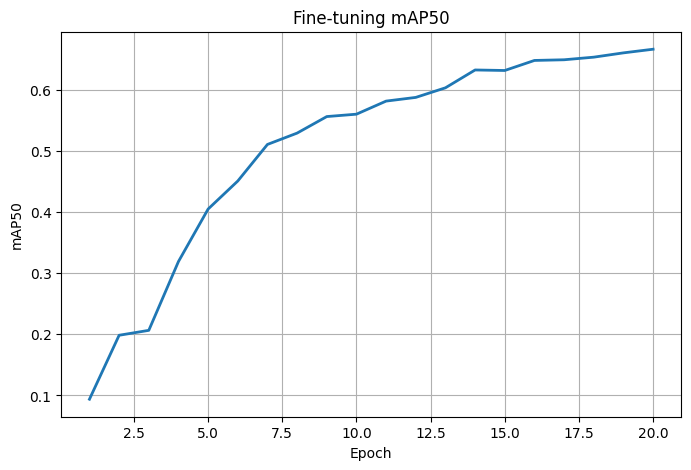

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["metrics/mAP50(B)"], linewidth=2)
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("Fine-tuning mAP50")
plt.show()

In [10]:
from ultralytics import YOLO

model = YOLO(os.path.join(RUN_DIR, "weights", "best.pt"))

metrics = model.val(
    data="/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/data_subset.yaml",
    imgsz=640,
    batch=16
)

print(metrics)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.8±1.7 ms, read: 20.9±6.4 MB/s, size: 99.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/labels/val.cache... 1144 images, 325 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1144/1144 399.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.3it/s 13.7s
                   all       1144       4470      0.714      0.593      0.666      0.329
Speed: 1.4ms preprocess, 3.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.ut

In [11]:
import os

LAST_MODEL = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/runs/thermal_yolov8n_subset/weights/last.pt"

print(os.path.exists(LAST_MODEL))

True


In [13]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/runs/thermal_yolov8n_subset/weights/last.pt")
model.train(resume=True)

WARNING ⚠️ model '/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/runs/thermal_yolov8n_subset/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c3697a5e210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [14]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")
metrics = model.val()
print(metrics)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1604.4±344.0 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.1it/s 0.2s
                   all          4         17          0          0          0          0
                person          3         10          0          0          0          0
                   dog          1          1          0          0          0          0
                 horse          1          2          0          0          0          0
              elephant          1          2          0          0          0          0
              umbrella          1          1         

In [17]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/runs/thermal_yolov8n_subset/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val",
    save=True,
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1144 /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val/video-57kWWRyeqqHs3Byei-frame-000816-b6tuLjNco8MfoBs3d.jpg: 512x640 4 persons, 39.4ms
image 2/1144 /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val/video-57kWWRyeqqHs3Byei-frame-000831-dsrhuE2hoMsERqDZT.jpg: 512x640 5 pers

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[  6,   6,   6],
         [ 12,  12,  12],
         [  5,   5,   5],
         ...,
         [ 70,  70,  70],
         [ 65,  65,  65],
         [ 80,  80,  80]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  4,   4,   4],
         ...,
         [ 78,  78,  78],
         [ 64,  64,  64],
         [ 72,  72,  72]],
 
        [[  7,   7,   7],
         [  7,   7,   7],
         [  0,   0,   0],
         ...,
         [ 76,  76,  76],
         [ 79,  79,  79],
         [ 71,  71,  71]],
 
        ...,
 
        [[218, 218, 218],
         [209, 209, 209],
         [204, 204, 204],
         ...,
         [216, 216, 216],
         [205, 205, 205],
         [207, 207, 207]],
 
        [[210, 210, 210],
         [216, 216, 216],
         [203, 203, 203],
         ...,
         [212, 212

In [19]:
!ls runs/detect

predict  train	val  val-2  val-3


In [21]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val",
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/Thermal_Project",
    name="validation_predictions"
)

Output hidden; open in https://colab.research.google.com to view.

In [22]:
!cp runs/detect/train/weights/best.pt /content/drive/MyDrive/Thermal_Project/
!cp runs/detect/train/weights/last.pt /content/drive/MyDrive/Thermal_Project/

In [23]:
PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

OUTPUT_ROOT = f"{PROJECT_ROOT}/runs"

In [24]:
from ultralytics import YOLO
import os

PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "runs",
    "thermal_yolov8n_subset",
    "weights",
    "best.pt"
)

DATA_YAML = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "flir",
    "flir_yolo",
    "data_subset.yaml"
)

model = YOLO(MODEL_PATH)

metrics = model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=16,
    project=os.path.join(PROJECT_ROOT, "runs"),
    name="validation",
    exist_ok=True
)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.2±1.0 ms, read: 29.2±11.5 MB/s, size: 106.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/labels/val.cache... 1144 images, 325 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1144/1144 282.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 5.3it/s 13.6s
                   all       1144       4470      0.803      0.697      0.779      0.436
Speed: 1.5ms preprocess, 3.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/drive/MyDrive/thermal project/

In [25]:
from ultralytics import YOLO
import os

PROJECT_ROOT = "/content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance"

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "runs",
    "thermal_yolov8n_subset",
    "weights",
    "best.pt"
)

VAL_IMAGES = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "flir",
    "flir_yolo",
    "images",
    "val"
)

model = YOLO(MODEL_PATH)

model.predict(
    source=VAL_IMAGES,
    conf=0.25,
    save=True,
    project=os.path.join(PROJECT_ROOT, "runs"),
    name="inference",
    exist_ok=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1144 /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val/video-57kWWRyeqqHs3Byei-frame-000816-b6tuLjNco8MfoBs3d.jpg: 512x640 4 persons, 13.1ms
image 2/1144 /content/drive/MyDrive/thermal project/Thermal-RGB-Integrated-Detection-with-Encoded-Noise-Tolerance/datasets/flir/flir_yolo/images/val/video-57kWWRyeqqHs3Byei-frame-000831-dsrhuE2hoMsERqDZT.jpg: 512x640 5 pers

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[  6,   6,   6],
         [ 12,  12,  12],
         [  5,   5,   5],
         ...,
         [ 70,  70,  70],
         [ 65,  65,  65],
         [ 80,  80,  80]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  4,   4,   4],
         ...,
         [ 78,  78,  78],
         [ 64,  64,  64],
         [ 72,  72,  72]],
 
        [[  7,   7,   7],
         [  7,   7,   7],
         [  0,   0,   0],
         ...,
         [ 76,  76,  76],
         [ 79,  79,  79],
         [ 71,  71,  71]],
 
        ...,
 
        [[218, 218, 218],
         [209, 209, 209],
         [204, 204, 204],
         ...,
         [216, 216, 216],
         [205, 205, 205],
         [207, 207, 207]],
 
        [[210, 210, 210],
         [216, 216, 216],
         [203, 203, 203],
         ...,
         [212, 212